# Read Counts

In [1]:
library(dplyr)
library(stringr)
library(tidyr)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Initial - QC

In [2]:
# raw and trimmed reads were written via script - found in 0QC_trimming-all
    # combining and pivoting to make easier to read

In [3]:
setwd('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/')
reads<-read.csv('reads.csv')
sampleids<-read.table('sampleids.txt', sep = "",header = FALSE)
sampleids$sampleid <- sampleids$V1
sampleids$V1 <- NULL

In [4]:
# make sure raw read counts R1 and R2 match
raw_read_match<-reads %>%
    filter(step == 'raw') %>%
    # add base sampleid to match by
    mutate(sampleid = str_remove(sample, "_R[12]_001.fastq")) %>%
    group_by(sampleid) %>%
    # make sure there are 2 seqs per sameplid and that there is only 1 distinct value (meaning they have the same read count)
    mutate(reads_match = case_when(
      n() == 2 & n_distinct(read_count) == 1 ~ TRUE,
      TRUE ~ FALSE
  )) %>%
  ungroup()

# make sure there are no falses
raw_read_match %>%
    filter(reads_match == FALSE)

# perfect they all match 

sample,read_count,step,sampleid,reads_match
<chr>,<int>,<chr>,<chr>,<lgl>


In [5]:
# check sample numbers match 
nsample<-nrow(sampleids) # 225 samples
nsample*2

nrow(reads%>%filter(step=='raw'))
# extra sample is "Undetermined"

[1] 450

[1] 452

In [6]:
# filter for just one Read per sample
raw_reads <-raw_read_match %>%
    group_by(sampleid, read_count) %>%
    slice_head(n=1) %>%
    ungroup() %>%
    select(-sample,-reads_match)
nrow(raw_reads)

[1] 226

In [7]:
# separate trimmed step 
trimmed<-reads %>%
    filter(step == 'trimmed') %>%
    # add base ID 
    mutate(sampleid = str_remove(sample, "_R[1]_001")) %>%
    select(-sample)
# and add raw back in 
reads_all<-rbind(raw_reads,trimmed)

In [8]:
# then pivot
reads_wide<-reads_all%>%
    pivot_wider(names_from = step,
                values_from = read_count)
print(reads_wide)

# A tibble: 226 × 3
   sampleid                        raw   trimmed
   <chr>                         <int>     <int>
 1 052022_BEL_CBC_T1_10_PSTR  68572842  68449647
 2 052022_BEL_CBC_T1_11_PSTR  48741905  48660782
 3 052022_BEL_CBC_T1_12_MCAV 166267321 165624856
 4 052022_BEL_CBC_T1_13_MCAV  86263796  86076666
 5 052022_BEL_CBC_T1_1_PAST   85047990  84808864
 6 052022_BEL_CBC_T1_34_PAST  31359387  31274591
 7 052022_BEL_CBC_T1_35_OANN  55101910  55033169
 8 052022_BEL_CBC_T1_39_MCAV  83479374  83235507
 9 052022_BEL_CBC_T1_40_MCAV  68897750  68586963
10 052022_BEL_CBC_T1_41_OANN  40011606  39927902
# ℹ 216 more rows


In [9]:
head(reads_all)
head(reads_wide)

read_count,step,sampleid
<int>,<chr>,<chr>
68572842,raw,052022_BEL_CBC_T1_10_PSTR
48741905,raw,052022_BEL_CBC_T1_11_PSTR
166267321,raw,052022_BEL_CBC_T1_12_MCAV
86263796,raw,052022_BEL_CBC_T1_13_MCAV
85047990,raw,052022_BEL_CBC_T1_1_PAST
31359387,raw,052022_BEL_CBC_T1_34_PAST


sampleid,raw,trimmed
<chr>,<int>,<int>
052022_BEL_CBC_T1_10_PSTR,68572842,68449647
052022_BEL_CBC_T1_11_PSTR,48741905,48660782
052022_BEL_CBC_T1_12_MCAV,166267321,165624856
052022_BEL_CBC_T1_13_MCAV,86263796,86076666
052022_BEL_CBC_T1_1_PAST,85047990,84808864
052022_BEL_CBC_T1_34_PAST,31359387,31274591


In [10]:
# change incorrect sample id (wrong specie)
reads_wide<-reads_wide %>%
    mutate(sampleid = if_else(sampleid=='052022_BEL_CBC_T1_63_OFAV','052022_BEL_CBC_T1_63_OANN',sampleid))
reads_all<-reads_all %>%
    mutate(sampleid = if_else(sampleid=='052022_BEL_CBC_T1_63_OFAV','052022_BEL_CBC_T1_63_OANN',sampleid))

In [11]:
# rewrite long and wide format

In [12]:
# reorder columns 
reads_all <- reads_all[, c('sampleid','read_count','step')]

In [13]:
# write.csv(reads_all,'reads_filtered.txt', row.names = FALSE, quote = FALSE)
# write.table(reads_wide,'reads_wide.txt', sep = "\t",row.names = FALSE, quote = FALSE)

In [14]:
# percentage lost in trimming step?
reads_wide<-reads_wide %>%
    mutate(pct_yield = round((trimmed / raw) * 100,2))
reads_wide %>% arrange(pct_yield)

sampleid,raw,trimmed,pct_yield
<chr>,<int>,<int>,<dbl>
7_3_Neg,6030707,5925379,98.25
7_11_Neg,21262507,21046368,98.98
052022_BEL_CBC_T2_60_PAST,104718356,103807571,99.13
052022_BEL_CBC_T1_52_PAST,94884365,94301477,99.39
052022_BEL_CBC_T1_61_PAST,74286118,73869279,99.44
062019_BEL_CBC_T2_2_PAST,28081060,27923531,99.44
122022_BEL_CBC_T1_150_PAST,33672160,33493920,99.47
052022_BEL_CBC_T2_10_MCAV,86868928,86447447,99.51
052022_BEL_CBC_T3_40_MCAV,87769648,87360332,99.53


In [15]:
# sort into groups 
# read in metadata 
colony<-read.csv('CBC_ColonyData.csv')
sampledata<- read.csv('CBC_samples.csv')

In [16]:
sampledata_copy<-sampledata
sampledata<-sampledata %>%
    filter(Tubelabel_species %in% sampleids$sample) %>%
    filter(!(Sample_type %in% c('TEM','Probiotics','Syringe'))) %>%
    mutate(colony_id = paste0("T",TransectNum,"_",NewTagNum,"_",Species)) %>%
    select(-Country, -Location, -OldTagNum, -Time_sampled, -Time_processed, -Sample_type, -Sample_physical_location, -Extraction_physical_location, -Notes, -Date_sequenced) %>%
    rename(sampleid = Tubelabel_species)

In [17]:
# add to seq data 
reads_combined<-reads_wide %>% 
    left_join(sampledata, by = 'sampleid')

In [18]:
options(repr.plot.height = 8, repr.plot.width = 10)

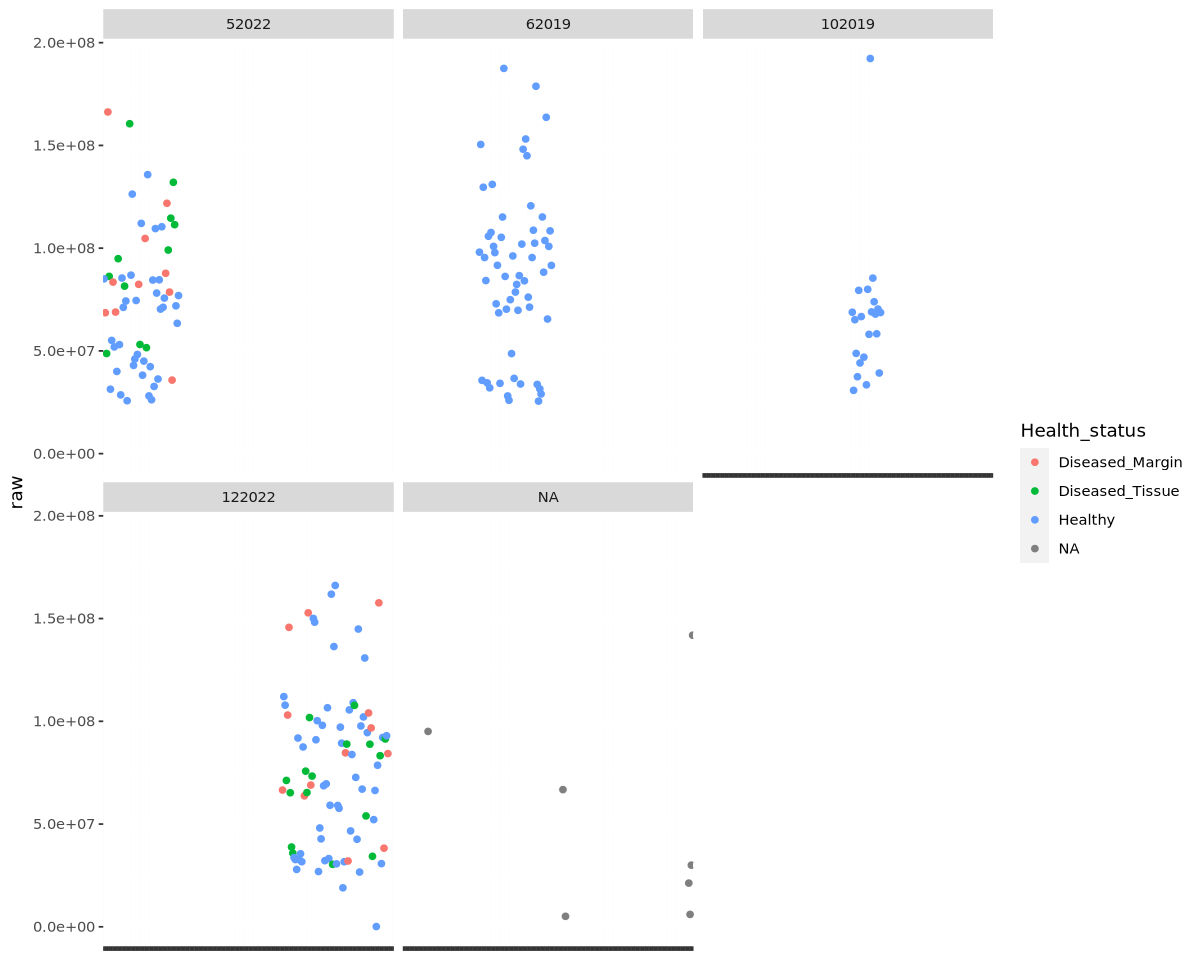

In [19]:
# view num of reads per sample - identify outliers 
ggplot(reads_combined, aes(x=sampleid, y = raw, color = Health_status))+
    geom_point()+
    facet_wrap(~Month_year)+
    theme(axis.title.x=element_blank(),
        axis.text.x=element_blank())

In [20]:
# pretty even spread across time points
# lets look at seqs with rly low reads 

In [21]:
head(reads_wide %>% arrange(raw),20)
# definitely not good that some of these are lower than the negatives 
# can look more at these after next step? not sure what to do yet 
# will probably have to get rid of the 120222_t4_3_mcav since it is lowest 

sampleid,raw,trimmed,pct_yield
<chr>,<int>,<int>,<dbl>
122022_BEL_CBC_T4_3_MCAV,120943,120525,99.65
102019_BEL_CBC_T2_31_PSTR_host,5100949,NA,NA
7_3_Neg,6030707,5925379,98.25
122022_BEL_CBC_T3_127_OFAV,18979588,18941021,99.80
7_11_Neg,21262507,21046368,98.98
062019_BEL_CBC_T3_24_PAST,25554334,25506424,99.81
052022_BEL_CBC_T1_62_MCAV,25748617,25677123,99.72
062019_BEL_CBC_T2_20_PAST,25959288,25903510,99.79
052022_BEL_CBC_T2_72_OFAV,26234287,26188996,99.83


In [22]:
# how can i find like samples with the lowest 10% of read coverage 
summary(reads_wide)

   sampleid              raw               trimmed            pct_yield    
 Length:226         Min.   :   120943   Min.   :   120525   Min.   :98.25  
 Class :character   1st Qu.: 45291641   1st Qu.: 45459415   1st Qu.:99.72  
 Mode  :character   Median : 74727471   Median : 74764042   Median :99.78  
                    Mean   : 77443169   Mean   : 77335407   Mean   :99.75  
                    3rd Qu.: 99991119   3rd Qu.: 99357026   3rd Qu.:99.83  
                    Max.   :192301811   Max.   :191938002   Max.   :99.88  
                                        NA's   :3           NA's   :3      

In [23]:
# maybe look at everything lower than the first quartile?
reads_wide %>%
    filter(raw < 45291641) %>% 
    arrange(raw)
# 57 samples lower than first quartile

sampleid,raw,trimmed,pct_yield
<chr>,<int>,<int>,<dbl>
122022_BEL_CBC_T4_3_MCAV,120943,120525,99.65
102019_BEL_CBC_T2_31_PSTR_host,5100949,NA,NA
7_3_Neg,6030707,5925379,98.25
122022_BEL_CBC_T3_127_OFAV,18979588,18941021,99.80
7_11_Neg,21262507,21046368,98.98
062019_BEL_CBC_T3_24_PAST,25554334,25506424,99.81
052022_BEL_CBC_T1_62_MCAV,25748617,25677123,99.72
062019_BEL_CBC_T2_20_PAST,25959288,25903510,99.79
052022_BEL_CBC_T2_72_OFAV,26234287,26188996,99.83


In [24]:
low <- quantile(reads_wide$raw, probs = 0.10)

low_samples <- reads_wide %>%
  filter(raw < low) %>%
  arrange(raw)

low_samples

sampleid,raw,trimmed,pct_yield
<chr>,<int>,<int>,<dbl>
122022_BEL_CBC_T4_3_MCAV,120943,120525,99.65
102019_BEL_CBC_T2_31_PSTR_host,5100949,NA,NA
7_3_Neg,6030707,5925379,98.25
122022_BEL_CBC_T3_127_OFAV,18979588,18941021,99.80
7_11_Neg,21262507,21046368,98.98
062019_BEL_CBC_T3_24_PAST,25554334,25506424,99.81
052022_BEL_CBC_T1_62_MCAV,25748617,25677123,99.72
062019_BEL_CBC_T2_20_PAST,25959288,25903510,99.79
052022_BEL_CBC_T2_72_OFAV,26234287,26188996,99.83


In [25]:
# set thresholds - see how many samples fall into each?
# need to read to determine what the thresholds should be 
reads_wide <- reads_wide %>%
  mutate(qc_status = case_when(
      raw < 1e6 ~ "Fail (<1M)",
      raw < 1e7 ~ "Low (1M-10M)",
      TRUE ~ "Pass (>10M)"
  ))

In [26]:
reads_wide %>%
    group_by(qc_status) %>%
    summarise(n = n())

qc_status,n
<chr>,<int>
Fail (<1M),1
Low (1M-10M),2
Pass (>10M),223


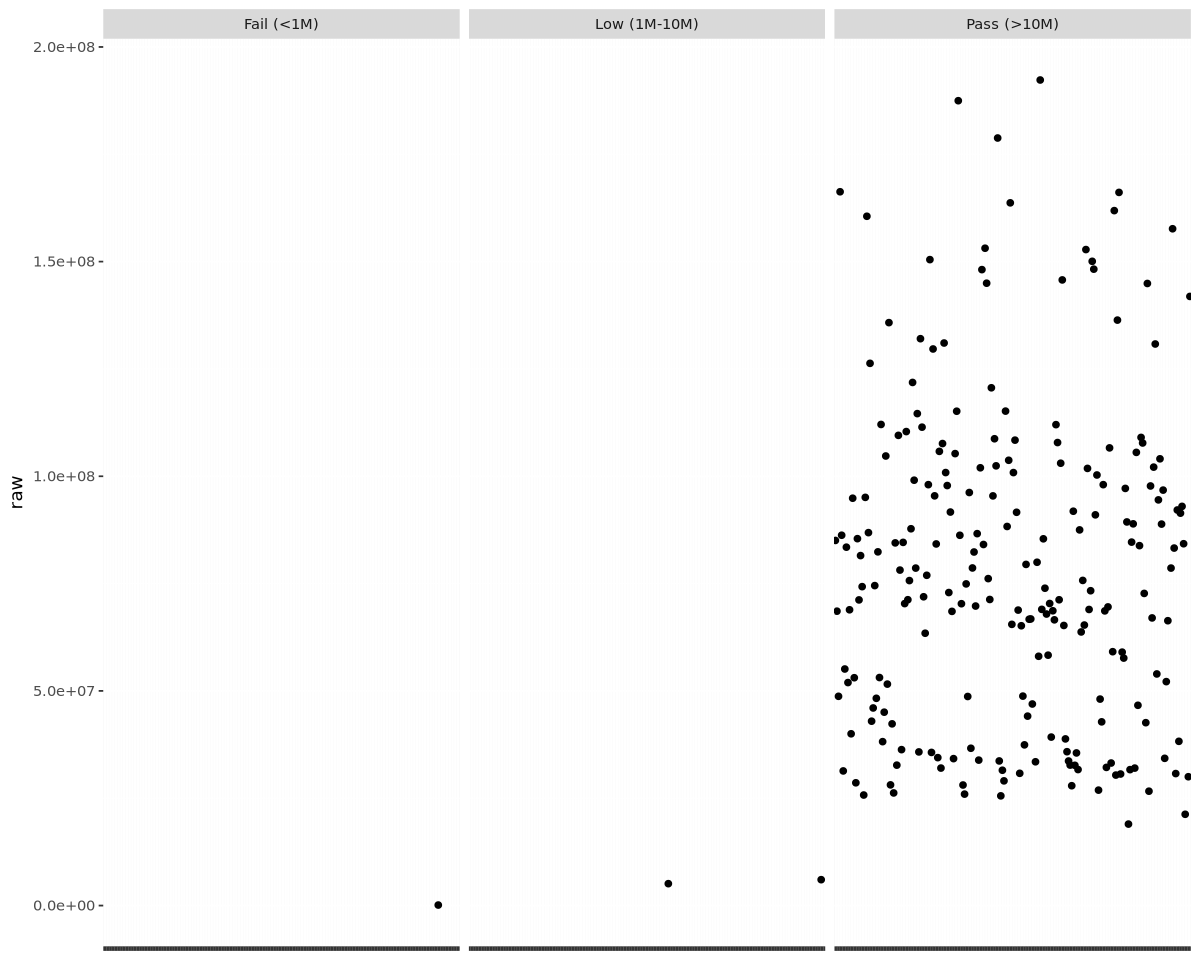

In [27]:
# view num of reads per sample - identify outliers 
ggplot(reads_wide, aes(x=sampleid, y = raw))+
    geom_point()+
    facet_wrap(~qc_status)+
    theme(axis.title.x=element_blank(),
        axis.text.x=element_blank())

In [28]:
reads_wide %>%
    filter(!(qc_status == "Pass (>10M)"))

sampleid,raw,trimmed,pct_yield,qc_status
<chr>,<int>,<int>,<dbl>,<chr>
102019_BEL_CBC_T2_31_PSTR_host,5100949,NA,NA,Low (1M-10M)
122022_BEL_CBC_T4_3_MCAV,120943,120525,99.65,Fail (<1M)
7_3_Neg,6030707,5925379,98.25,Low (1M-10M)


In [29]:
# can deffs filter these out for now and then decide about the rest??
# just filtering out hosts and this 1 sample, going to assemble negatives together

In [30]:
reads_filtered<-reads_wide$sampleid[names(reads_wide$sampleid) %in% c('102019_BEL_CBC_T2_31_PSTR_host','102019_BEL_CBC_T2_30_PSTR_host','122022_BEL_CBC_T4_3_MCAV')]

In [31]:
filtered_samples<-reads_wide$sampleid[!(reads_wide$sampleid %in% c('102019_BEL_CBC_T2_31_PSTR_host','102019_BEL_CBC_T2_30_PSTR_host',
                                                 '122022_BEL_CBC_T4_3_MCAV',"Undetermined"))]

In [32]:
# idk why cant fix oann rn so going to add data manually for now 
samplefix<-data.frame('sampleid' = '052022_BEL_CBC_T1_63_OANN','Month_year' = 52022, 'Transect' = 'CBC30N', 'TransectNum' = 1, 'NewTagNum' = '25', 
           'Species' = 'OANN', 'SampleNum' = '63', 'Health_status' = 'Healthy', 'colony_id' = 'T1_25_OANN')
reads_combined<-reads_combined %>%
    rows_update(samplefix, by = "sampleid")

In [33]:
reads_combined<-reads_combined %>%
# add metadata for negatives
    mutate(group = if_else(grepl("Neg",sampleid), "Negative", paste0(Month_year, "_", Species, "_", Health_status))) %>%
# and combine orbis
    mutate(Species = case_when(grepl("Neg",sampleid) ~"NEG",
                               Species == "OFAV" ~ "ORBI",
                               Species == "OANN" ~ "ORBI",
                               TRUE ~ Species))

In [34]:
# investigate NAs 
reads_combined %>%
    filter(grepl("NA",group))

sampleid,raw,trimmed,pct_yield,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,Sampling_notes,colony_id,group
<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
102019_BEL_CBC_T2_30_PSTR_host,66763853,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA_NA_NA
102019_BEL_CBC_T2_31_PSTR_host,5100949,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA_NA_NA
Undetermined,141888465,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA_NA_NA


In [35]:
# this is supposed to be an oann : 052022_BEL_CBC_T1_63_OFAV - will change sample name and everything from here but leaving raw files alone 
# 122022_BEL_CBC_T4_1_OFAV was misnumbered as #4 (found raw datasheet and corrected in sctld_samples)
# 122022_BEL_CBC_T4_8_PSTR was misnumbered as #3 (found raw datasheet and corrected in sctld_samples)

# reuploading metadata to fix these

In [36]:
unique(reads_combined$group)

[1] "52022_PSTR_Diseased_Margin"  "52022_PSTR_Diseased_Tissue" 
 [3] "52022_MCAV_Diseased_Margin"  "52022_MCAV_Diseased_Tissue" 
 [5] "52022_PAST_Healthy"          "52022_OANN_Healthy"         
 [7] "52022_PSTR_Healthy"          "52022_PAST_Diseased_Tissue" 
 [9] "52022_MCAV_Healthy"          "52022_OFAV_Healthy"         
[11] "52022_PAST_Diseased_Margin"  "62019_MMEA_Healthy"         
[13] "62019_PAST_Healthy"          "62019_MCAV_Healthy"         
[15] "102019_PSTR_Healthy"         "NA_NA_NA"                   
[17] "122022_OANN_Diseased_Margin" "122022_PSTR_Healthy"        
[19] "122022_OANN_Healthy"         "122022_PSTR_Diseased_Tissue"
[21] "122022_PSTR_Diseased_Margin" "122022_PAST_Diseased_Margin"
[23] "122022_OANN_Diseased_Tissue" "122022_PAST_Diseased_Tissue"
[25] "122022_MCAV_Diseased_Tissue" "122022_PAST_Healthy"        
[27] "122022_MCAV_Healthy"         "122022_OFAV_Diseased_Margin"
[29] "122022_OFAV_Diseased_Tissue" "122022_OFAV_Healthy"        
[31] "122022_MCAV_Diseased_Margin" "Negative"

In [37]:
# filter out unusable samples in reads_combined
reads_combined<-reads_combined %>% filter(sampleid %in% filtered_samples) %>% select (-Sampling_notes)

In [38]:
# add group and spp to filtered sample list 
head(filtered_samples)
filtered_sample_group<-reads_combined %>%
    select(sampleid,Species,group) %>%
    rename(specie = Species)
tail(filtered_sample_group)

[1] "052022_BEL_CBC_T1_10_PSTR" "052022_BEL_CBC_T1_11_PSTR"
[3] "052022_BEL_CBC_T1_12_MCAV" "052022_BEL_CBC_T1_13_MCAV"
[5] "052022_BEL_CBC_T1_1_PAST"  "052022_BEL_CBC_T1_34_PAST"

sampleid,specie,group
<chr>,<chr>,<chr>
122022_BEL_CBC_T4_6_MCAV,MCAV,122022_MCAV_Diseased_Tissue
122022_BEL_CBC_T4_8_PSTR,PSTR,122022_PSTR_Healthy
122022_BEL_CBC_T4_9_OFAV,ORBI,122022_OFAV_Diseased_Margin
7_11_Neg,NEG,Negative
7_3_Neg,NEG,Negative
Negative_extract_11-2-24,NEG,Negative


In [39]:
# write.table(filtered_sample_group, 'filtered_sample_groups.txt', row.names = FALSE, quote = FALSE, sep = '\t')
write.csv(reads_combined, "reads_meta.csv", row.names = FALSE, quote = FALSE)

In [168]:
# need to create appendix for all of these freakin files i created

# filtered_sample_group.txt (filtered_sample_groups) = filtered sample list with spp and group
# filtered_samples.txt = filtered sample list 
# reads.csv = raw calculated reads from all samples: raw and trimmed steps
# reads_filtered = same as above but kept only one F/R read per sample
# reads_meta.csv (reads_combined) = read counts raw and trimmed with metadata, filtered samples



## Assembly Steps

### Multiqc in bash

In [ ]:
#!/bin/bash
#SBATCH -c 24  # Number of Cores per Task
#SBATCH --mem=50G  # Requested Memory
#SBATCH -p cpu  # Partition
#SBATCH -t 48:00:00  # Job time limit
#SBATCH --mail-type=ALL
#SBATCH -o /work/pi_sarah_gignouxwolfsohn_uml_edu/brooke/seqs042024/outputs/slurm-multiqc-%j.out  # %j = job ID

# run multiqc in both host removal and symbiont steps to calculate read count..
# get unique species from list of samples, spp, and groups

module load conda/latest
conda activate qc

slurm_dir="/work/pi_sarah_gignouxwolfsohn_uml_edu/brooke/seqs042024/outputs"
base_dir="/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw"
cd $base_dir

dir_list=$(ls -d */)
for dir in $dir_list; do 
    spp=${dir%/}
    echo "fastqc host_removed spp: ${spp}"
    fastqc ${spp}/assembly/host_removed/*.fastq* --threads 16
    echo "fastqc final_filtered spp: ${spp}"
    fastqc ${spp}/assembly/final_filtered/*_ready.fastq* --threads 16

    echo "multiqc spp: ${spp}"
    multiqc $base_dir/$spp/. $slurm_dir/$spp/. \
            -n "${spp}_QC_Report" \
            --outdir "${base_dir}/${spp}/assembly/qc_reports"
done

conda deactivate

# job id: 56139675, 56233305

### Read count review - python
file flow path:\
trimmed (${id}_R1_001_val_1.fq)\
-> host removed (host_removed_R1.fastq)\
-> symbiont, human fastqc (_host_removed_R1.tagged_filter.fastq.gz)\
-> repair (_host_removed_R1.tagged_filter_ready.fastq.gz)

In [36]:
import os
import gzip
# from Bio import SeqIO
import pandas as pd
import re
import numpy as np
from pathlib import Path

In [37]:
# set dir
os.chdir('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/')

In [38]:
# upload all multiqc reports and compile

# upload all qc results
    # i think this has pre and post host removal - so can subtract to get read matches??
pattern = "*/assembly/qc_reports/*_QC_Report_data/multiqc_fastqc.txt"
files = list(Path('.').glob(pattern))

# import all into single df
df_list = [pd.read_csv(f, sep='\t') for f in files]
fastqc_df = pd.concat(df_list, ignore_index=True)

# repeat for genome alignments - symbiont, human
pattern = "*/assembly/qc_reports/*_QC_Report_data/multiqc_fastq_screen.txt"
files = list(Path('.').glob(pattern))
df_list = [pd.read_csv(f, sep='\t') for f in files]
multiqc_df = pd.concat(df_list, ignore_index=True)

#### Host removal and repair step
- (I know these steps are out of order but they're both in 1 file)
- fastqc multiqc results -> extract "Sequences" from each "host_removed" file
- comparing to trimmed will get you alignment %
    - (can also look at slurm output but bc I ran so many times I think this will be easiest for now) 

In [39]:
# extract sampleids and step
fastqc_df['sampleid'] = fastqc_df['Sample'].str.extract(r'(.*)_host')

# if str contains 'tagged_filter_ready', make step 'repaired' - if not, 'host_removal'
# np.where is like if_else but for entire array at once
fastqc_df['step'] = np.where(
    fastqc_df['Sample'].str.contains('tagged_filter_ready'), 
    'repaired', 
    'host_removal')

In [40]:
fastqc_df.columns

Index(['Sample', 'Filename', 'File type', 'Encoding', 'Total Sequences',
       'Total Bases', 'Sequences flagged as poor quality', 'Sequence length',
       '%GC', 'total_deduplicated_percentage', 'avg_sequence_length',
       'median_sequence_length', 'basic_statistics',
       'per_base_sequence_quality', 'per_tile_sequence_quality',
       'per_sequence_quality_scores', 'per_base_sequence_content',
       'per_sequence_gc_content', 'per_base_n_content',
       'sequence_length_distribution', 'sequence_duplication_levels',
       'overrepresented_sequences', 'adapter_content', 'sampleid', 'step'],
      dtype='object')

In [41]:
# check that all R1 and R2 match - then remove R2
check = fastqc_df.groupby(['sampleid', 'step']).agg({'Total Sequences': 'nunique'})
print(check[check['Total Sequences'] > 1])

fastqc_df = fastqc_df[fastqc_df['Sample'].str.contains('_R1')]

Empty DataFrame
Columns: [Total Sequences]
Index: []


In [42]:
# for now just keep the few columns
host_step_counts=fastqc_df.loc[:,['sampleid','Sample','step','Total Sequences']]
host_step_counts=host_step_counts.rename(columns={'Total Sequences': 'reads'})

In [43]:
host_step_counts.shape
# i might be missing a sample??

(442, 4)

In [44]:
host_step_counts[host_step_counts['reads'].isna()]

,sampleid,Sample,step,reads


In [45]:
# investigate negatives here
host_step_counts[host_step_counts['Sample'].str.contains('neg', case=False, na=False)]
#reassign manually
host_step_counts.loc[555, 'sampleid'] = '7_11_Neg_final'
host_step_counts.loc[559, 'sampleid'] = '7_3_Neg_final'


#### Symbiont, human
- have to treat these as combined filtering
- if interested in symbiont mapping, view separately than overall read counts table

In [46]:
print(multiqc_df.head(3))
print(multiqc_df.shape)
# ok so total_reads = input reads (number of reads in host_removed file before filtering)
# no hits counts = output reads (reads that matched and were filtered out), these go on to next step 

                                             Sample  total_reads  \
0  052022_BEL_CBC_T1_35_OANN_host_removed_R1_screen     20263133   
1  052022_BEL_CBC_T1_35_OANN_host_removed_R2_screen     20263133   
2  052022_BEL_CBC_T1_41_OANN_host_removed_R1_screen     11347352   

   Human counts  Human percentage  Symbiont1 counts  Symbiont1 percentage  \
0      391362.0              1.93          511515.0                  2.52   
1      427477.0              2.11          565874.0                  2.79   
2      219522.0              1.93          491968.0                  4.34   

   Symbiont2 counts  Symbiont2 percentage  Symbiont3 counts  \
0          610476.0                  3.02         2056638.0   
1          664377.0                  3.28         2096339.0   
2          272184.0                  2.40          600734.0   

   Symbiont3 percentage  ...  Symbiont8 counts  Symbiont8 percentage  \
0                 10.15  ...          587502.0                  2.89   
1                 10.

In [48]:
# new df
# sampleid, step, reads

In [49]:
# extract sample id - think i need to keep R1 and R2 separate here??
multiqc_df['sampleid'] = multiqc_df['Sample'].str.extract(r'(.*)_host')

# subtract human counts from total_reads
multiqc_df['human_removal_counts']= multiqc_df['total_reads']-multiqc_df['Human counts']

# extract columns 
human_counts=multiqc_df.loc[:,['sampleid','Sample','human_removal_counts']]
human_counts['step']='human_removal'
human_counts=human_counts.rename(columns={'human_removal_counts': 'reads'})

In [51]:
# cannot estimate symbiont total (bc of overlapping alignment) nor without human
# so just guestimating 
symb_human_counts=multiqc_df.loc[:,['sampleid','Sample','No hits counts']]
symb_human_counts['step']='human_symb_removal'
symb_human_counts=symb_human_counts.rename(columns={'No hits counts': 'reads'})

In [52]:
# combine
symb_human_counts=pd.concat([human_counts,symb_human_counts])
# and with previous step
filter_counts=pd.concat([host_step_counts,symb_human_counts])

In [53]:
filter_counts[filter_counts['Sample'].str.contains('neg', case=False, na=False)]

,sampleid,Sample,step,reads
555,7_11_Neg_final,7_11_Neg_R1.tagged_filter_ready,repaired,19594581.0
557,7_11_Neg_final,7_11_Neg_final_host_removed_R1,host_removal,21028565.0
559,7_3_Neg_final,7_3_Neg_R1.tagged_filter_ready,repaired,5363983.0
561,7_3_Neg_final,7_3_Neg_final_host_removed_R1,host_removal,5924645.0
563,Negative_extract_11-2-24_final,Negative_extract_11-2-24_final_host_removed_R1,host_removal,29875291.0
278,7_11_Neg_final,7_11_Neg_final_host_removed_R1_screen,human_removal,20845717.0
279,7_11_Neg_final,7_11_Neg_final_host_removed_R2_screen,human_removal,19915078.0
280,7_3_Neg_final,7_3_Neg_final_host_removed_R1_screen,human_removal,5738714.0
281,7_3_Neg_final,7_3_Neg_final_host_removed_R2_screen,human_removal,5461918.0
278,7_11_Neg_final,7_11_Neg_final_host_removed_R1_screen,human_symb_removal,20702622.0


In [54]:
filter_countswide=filter_counts.pivot_table(
    index='sampleid', 
    columns='step', 
    values='reads', 
    aggfunc='first'
).reset_index()

In [55]:
# calculate missing symbiont value 
filter_countswide['est_symbiont_removal'] = filter_countswide['human_removal'] - filter_countswide['human_symb_removal']

In [56]:
filter_countswide
# rerun symbiont mapping for 11-2 neg extract

step,sampleid,host_removal,human_removal,human_symb_removal,repaired,est_symbiont_removal
0,052022_BEL_CBC_T1_10_PSTR,28910191.0,28678437.0,28187436.0,27922584.0,491001.0
1,052022_BEL_CBC_T1_11_PSTR,23319939.0,23136007.0,20372298.0,20064803.0,2763709.0
2,052022_BEL_CBC_T1_12_MCAV,53609962.0,52442516.0,16897860.0,15467061.0,35544656.0
3,052022_BEL_CBC_T1_13_MCAV,82372839.0,80609004.0,8467927.0,6251710.0,72141077.0
4,052022_BEL_CBC_T1_1_PAST,83379066.0,82708985.0,79310167.0,78064852.0,3398818.0
...,...,...,...,...,...,...
217,122022_BEL_CBC_T4_8_PSTR,39178799.0,38674143.0,31307778.0,30351117.0,7366365.0
218,122022_BEL_CBC_T4_9_OFAV,75826212.0,75373523.0,74848053.0,74283839.0,525470.0
219,7_11_Neg_final,21028565.0,20845717.0,20702622.0,19594581.0,143095.0
220,7_3_Neg_final,5924645.0,5738714.0,5691806.0,5363983.0,46908.0


#### Combine with previous steps and metadata

In [57]:
# upload previous read count steps with metadata
reads_meta=pd.read_csv('reads_meta.csv')
reads_meta.head()

,sampleid,raw,trimmed,pct_yield,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,colony_id,group
0,052022_BEL_CBC_T1_10_PSTR,68572842,68449647,99.82,52022.0,5/21/22,CBC30N,1.0,4,PSTR,10.0,Diseased_Margin,T1_4_PSTR,52022_PSTR_Diseased_Margin
1,052022_BEL_CBC_T1_11_PSTR,48741905,48660782,99.83,52022.0,5/21/22,CBC30N,1.0,4,PSTR,11.0,Diseased_Tissue,T1_4_PSTR,52022_PSTR_Diseased_Tissue
2,052022_BEL_CBC_T1_12_MCAV,166267321,165624856,99.61,52022.0,5/21/22,CBC30N,1.0,8,MCAV,12.0,Diseased_Margin,T1_8_MCAV,52022_MCAV_Diseased_Margin
3,052022_BEL_CBC_T1_13_MCAV,86263796,86076666,99.78,52022.0,5/21/22,CBC30N,1.0,8,MCAV,13.0,Diseased_Tissue,T1_8_MCAV,52022_MCAV_Diseased_Tissue
4,052022_BEL_CBC_T1_1_PAST,85047990,84808864,99.72,52022.0,5/21/22,CBC30N,1.0,2,PAST,1.0,Healthy,T1_2_PAST,52022_PAST_Healthy


In [58]:
reads_meta.shape
# should be 223 (see header of sample_check.ipynb)
    # jk 222 is right cuz filtered out one mcav with really low read count

(222, 14)

In [59]:
initial_reads=reads_meta.loc[:,['sampleid','raw','trimmed','Species','Transect','colony_id','Health_status','group']]

In [60]:
reads = pd.merge(filter_countswide, reads_meta, on='sampleid', how='left')

In [61]:
column_order = ['sampleid','raw', 'trimmed', 'host_removal','human_symb_removal', 'repaired',
                'Species','Transect','colony_id','Health_status','group']
reads = reads[column_order]

In [62]:
reads

,sampleid,raw,trimmed,host_removal,human_symb_removal,repaired,Species,Transect,colony_id,Health_status,group
0,052022_BEL_CBC_T1_10_PSTR,68572842.0,68449647.0,28910191.0,28187436.0,27922584.0,PSTR,CBC30N,T1_4_PSTR,Diseased_Margin,52022_PSTR_Diseased_Margin
1,052022_BEL_CBC_T1_11_PSTR,48741905.0,48660782.0,23319939.0,20372298.0,20064803.0,PSTR,CBC30N,T1_4_PSTR,Diseased_Tissue,52022_PSTR_Diseased_Tissue
2,052022_BEL_CBC_T1_12_MCAV,166267321.0,165624856.0,53609962.0,16897860.0,15467061.0,MCAV,CBC30N,T1_8_MCAV,Diseased_Margin,52022_MCAV_Diseased_Margin
3,052022_BEL_CBC_T1_13_MCAV,86263796.0,86076666.0,82372839.0,8467927.0,6251710.0,MCAV,CBC30N,T1_8_MCAV,Diseased_Tissue,52022_MCAV_Diseased_Tissue
4,052022_BEL_CBC_T1_1_PAST,85047990.0,84808864.0,83379066.0,79310167.0,78064852.0,PAST,CBC30N,T1_2_PAST,Healthy,52022_PAST_Healthy
...,...,...,...,...,...,...,...,...,...,...,...
217,122022_BEL_CBC_T4_8_PSTR,92985746.0,92780888.0,39178799.0,31307778.0,30351117.0,PSTR,CURLEW,T4_80_PSTR,Healthy,122022_PSTR_Healthy
218,122022_BEL_CBC_T4_9_OFAV,84282678.0,84134355.0,75826212.0,74848053.0,74283839.0,ORBI,CURLEW,T4_100_OFAV,Diseased_Margin,122022_OFAV_Diseased_Margin
219,7_11_Neg_final,NaN,NaN,21028565.0,20702622.0,19594581.0,NaN,NaN,NaN,NaN,NaN
220,7_3_Neg_final,NaN,NaN,5924645.0,5691806.0,5363983.0,NaN,NaN,NaN,NaN,NaN


#### Plot

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

In [66]:
steps = ['raw', 'trimmed', 'host_removal', 'human_symb_removal','repaired']
plot_df = pd.melt(
    reads, 
    id_vars=['sampleid', 'Species'], 
    value_vars=steps, 
    var_name='Step', 
    value_name='read_count')

In [134]:
# convert unit to million for plotting
plot_df['read_count_M'] = plot_df['read_count'] / 1_000_000

<Figure size 1500x800 with 0 Axes>

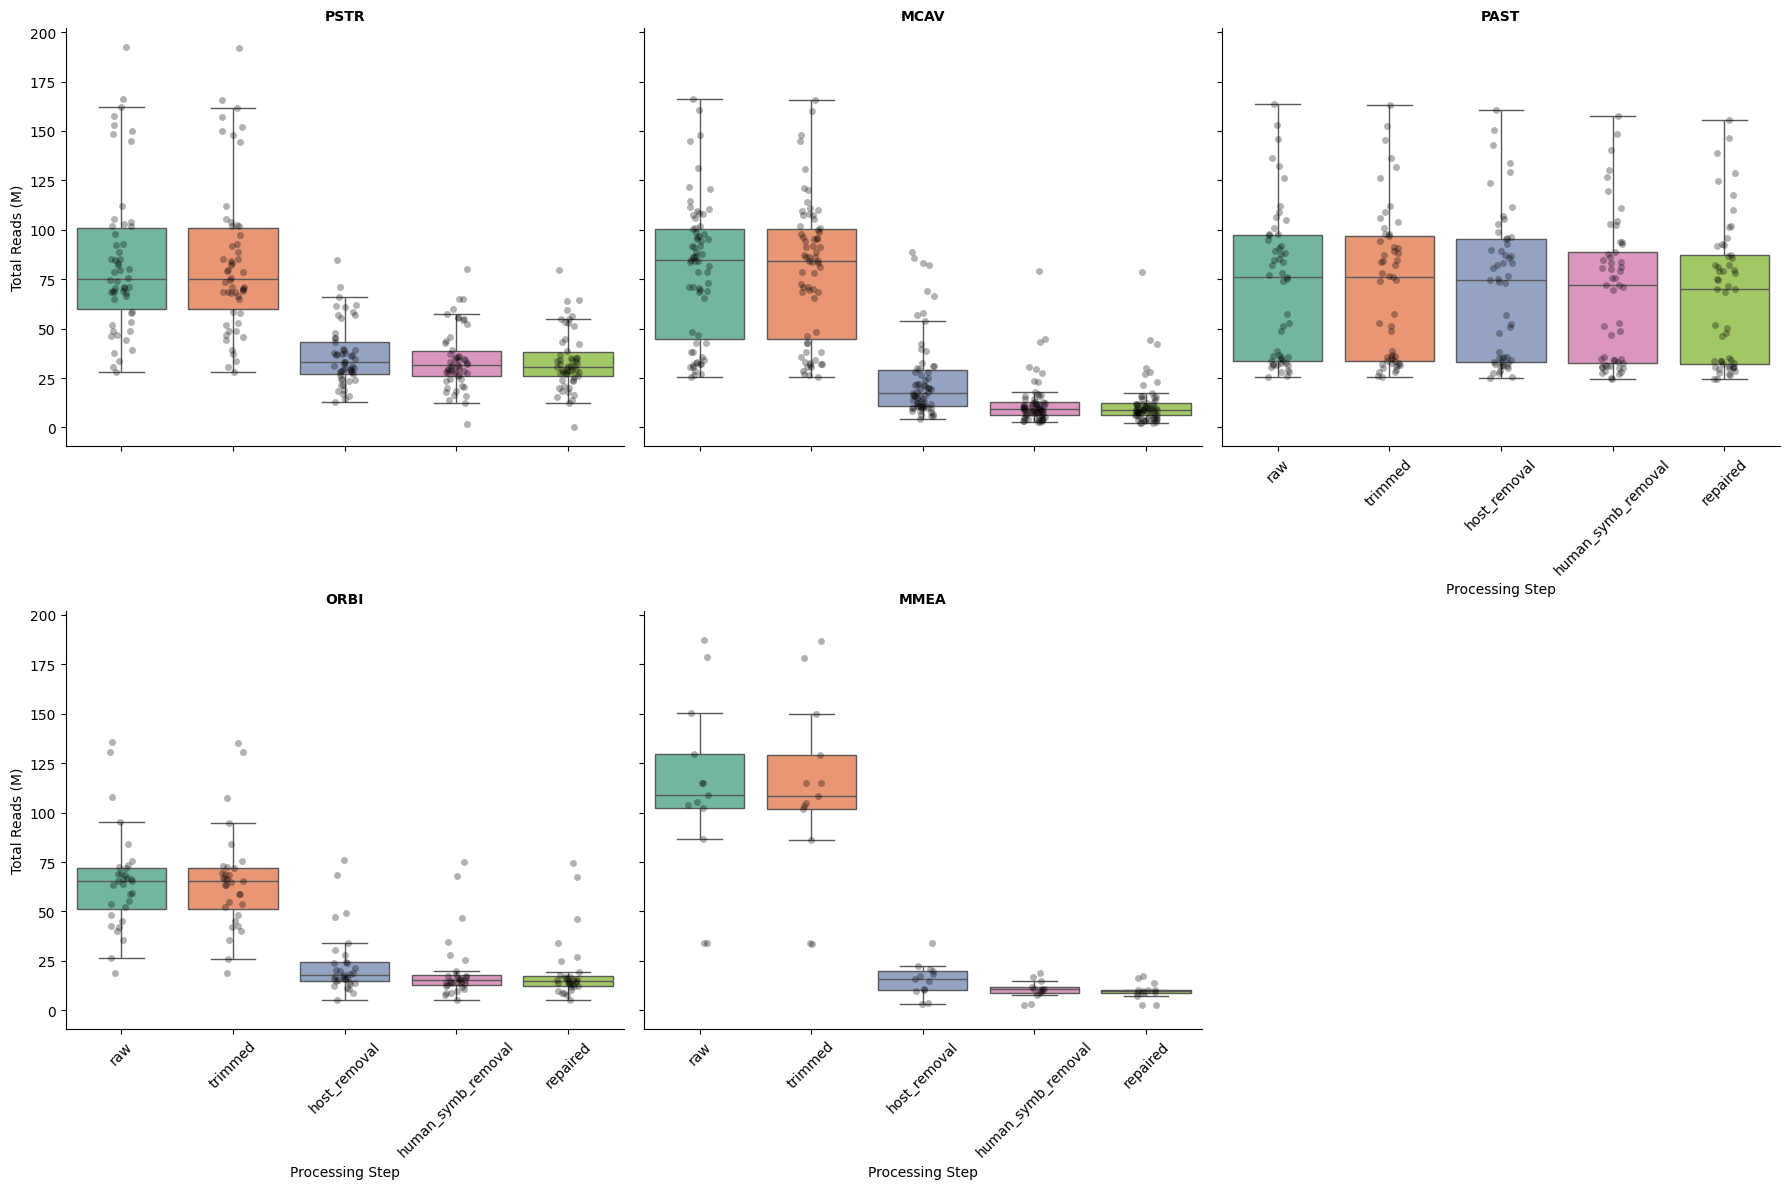

In [136]:
# help from gemini cuz havent used python in a while
plot_df['Step'] = pd.Categorical(plot_df['Step'], categories=steps, ordered=True)

plt.figure(figsize=(15, 8))

# Using catplot to create a grid of plots (one per species)
g = sns.catplot(data=plot_df, x='Step', y='read_count_M', col='Species', kind='box', 
    col_wrap=3,height=6,hue='Step', palette='Set2', legend=False,
                showfliers=False   # Points will be shown by stripplot instead
)
g.map_dataframe(sns.stripplot, x='Step', y='read_count_M', color='black', alpha=0.3, jitter=True)
g.set_axis_labels("Processing Step", "Total Reads (M)")
g.set_titles("{col_name}", weight='bold')
for ax in g.axes.flat:
    ax.tick_params(axis='x', labelrotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# tragic
# is PAST just fine wth. its not mapping to host though 
# PSTR mapped to host alot (CNAT) but is running into downstream issues

In [ ]:
# percent loss 
# after host removal then symbiont removal
reads.head()

In [78]:
reads['pct_host_aligned']=((reads['trimmed']-reads['host_removal']) / reads['trimmed'])*100

#### Host Alignment

Text(0.5, 0, 'Species')

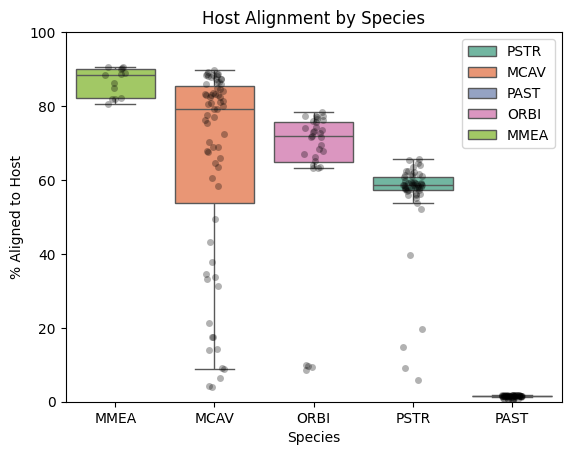

In [95]:
order = reads.groupby('Species')['pct_host_aligned'].median().sort_values(ascending=False).index
sns.boxplot(data=reads, x='Species', y='pct_host_aligned',
            order = order,
            palette = 'Set2',hue = 'Species',
            showfliers=False   # Points will be shown by stripplot instead
)
sns.stripplot(data=reads, x='Species', y='pct_host_aligned', color='black', 
    alpha=0.3, 
    jitter=True
)
plt.title('Host Alignment by Species')
plt.ylabel('% Aligned to Host')
plt.ylim(0, 100)
plt.xlabel('Species')

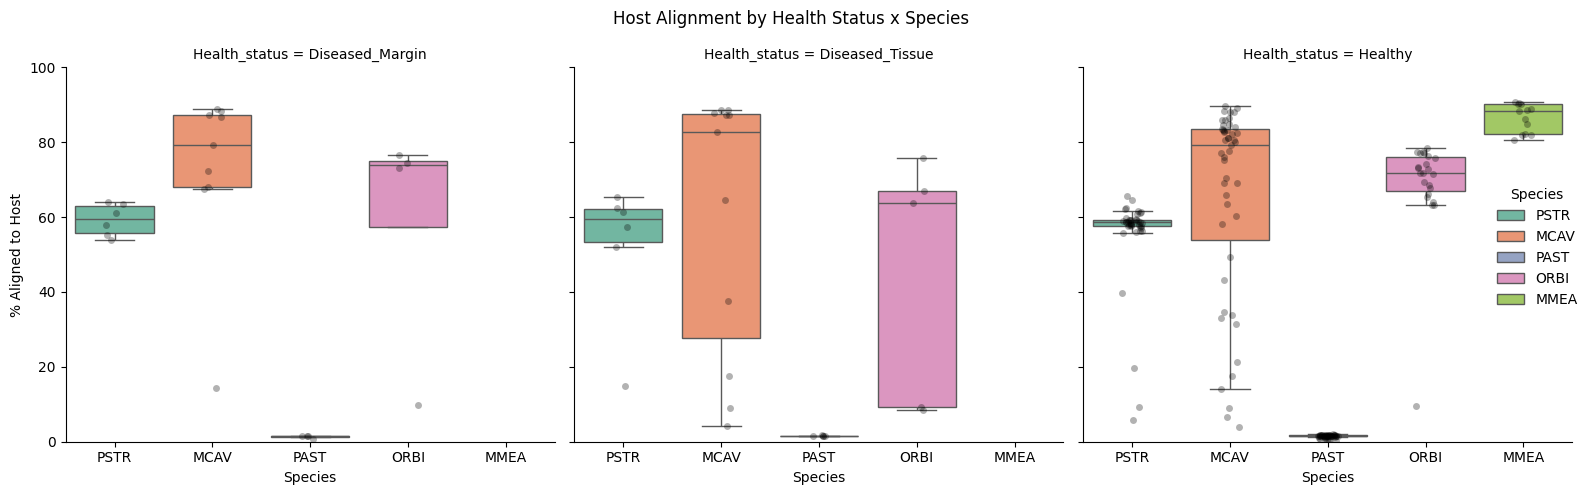

In [114]:
sp=sns.catplot(data=reads, x='Species', y='pct_host_aligned',col = 'Health_status',
            kind = 'box',
            # order = order,
            palette = 'Set2',hue = 'Species',
            showfliers=False
)
sp.map_dataframe(sns.stripplot,x='Species', y='pct_host_aligned', color='black',
                                 # order = order,
                 alpha=0.3, jitter=True
)
sp.fig.suptitle('Host Alignment by Health Status x Species')
sp.set_axis_labels('Species','% Aligned to Host')
sp.set(ylim=(0, 100))
plt.tight_layout()
plt.show()

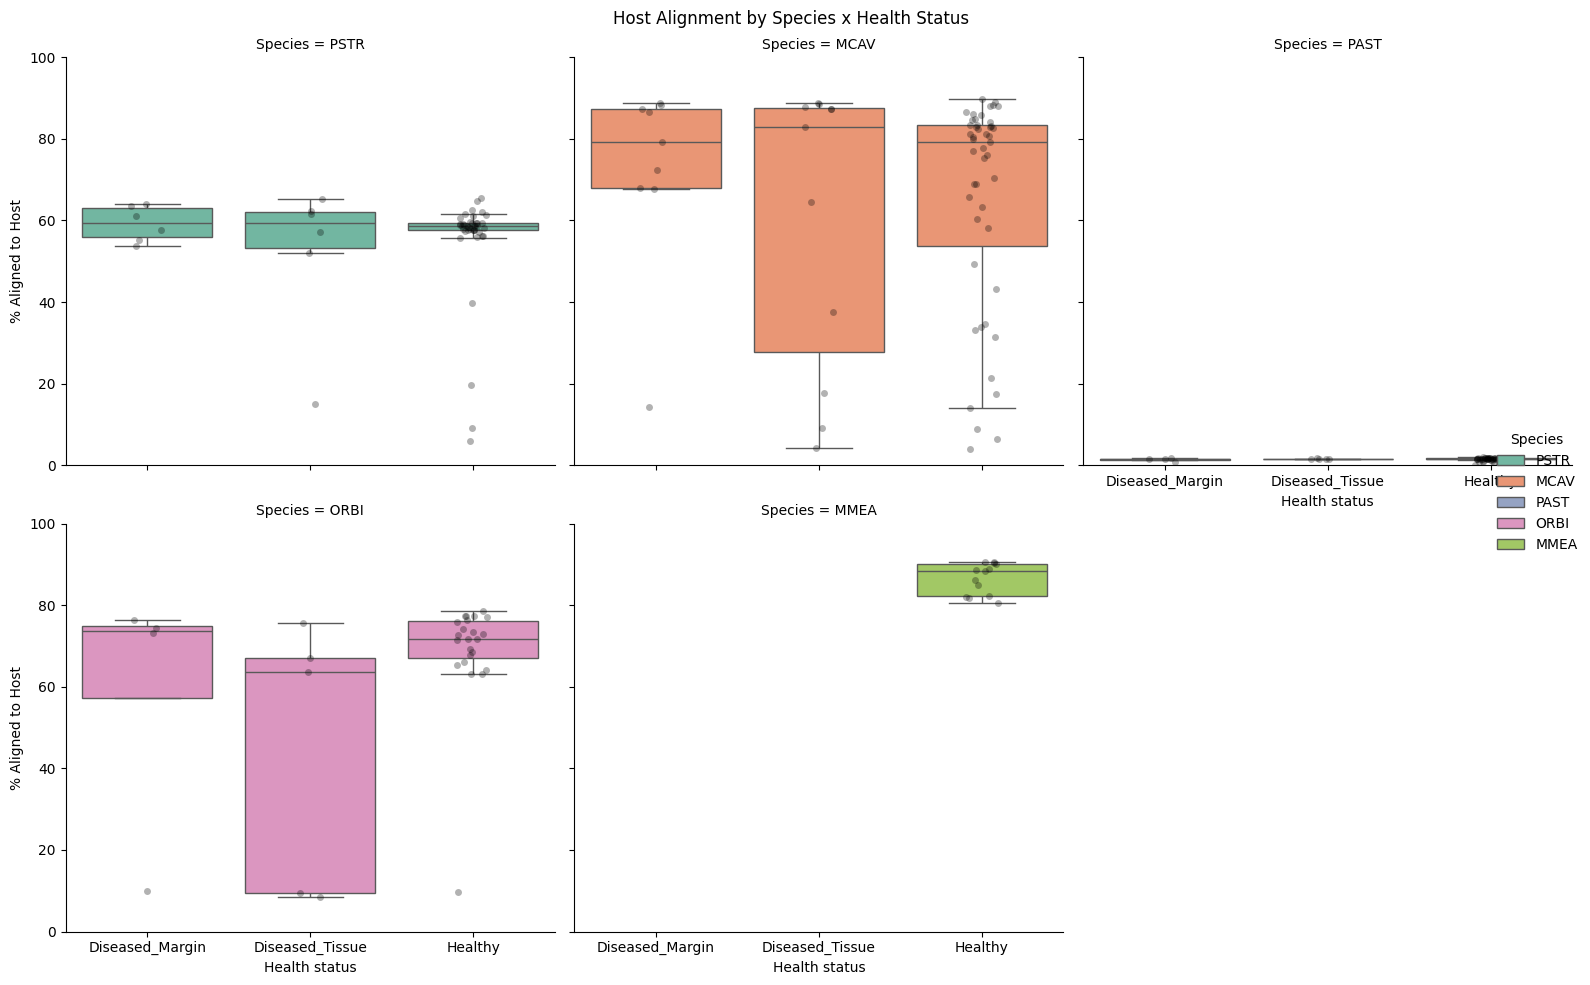

In [117]:
sp=sns.catplot(data=reads, x='Health_status', y='pct_host_aligned',col = 'Species',
            kind = 'box',
            # order = order,
            col_wrap = 3,
            palette = 'Set2',hue = 'Species',
            showfliers=False
)
sp.map_dataframe(sns.stripplot,x='Health_status', y='pct_host_aligned', color='black',
                                 # order = order,
                 alpha=0.3, jitter=True
)
sp.fig.suptitle('Host Alignment by Species x Health Status')
sp.set_axis_labels('Health status','% Aligned to Host')
sp.set(ylim=(0, 100))
plt.tight_layout()
plt.show()

#### Overall Read Counts x Spp

In [120]:
reads.head()

,sampleid,raw,trimmed,host_removal,human_symb_removal,repaired,Species,Transect,colony_id,Health_status,group,pct_host_aligned
0,052022_BEL_CBC_T1_10_PSTR,68572842.0,68449647.0,28910191.0,28187436.0,27922584.0,PSTR,CBC30N,T1_4_PSTR,Diseased_Margin,52022_PSTR_Diseased_Margin,57.764295
1,052022_BEL_CBC_T1_11_PSTR,48741905.0,48660782.0,23319939.0,20372298.0,20064803.0,PSTR,CBC30N,T1_4_PSTR,Diseased_Tissue,52022_PSTR_Diseased_Tissue,52.076522
2,052022_BEL_CBC_T1_12_MCAV,166267321.0,165624856.0,53609962.0,16897860.0,15467061.0,MCAV,CBC30N,T1_8_MCAV,Diseased_Margin,52022_MCAV_Diseased_Margin,67.631693
3,052022_BEL_CBC_T1_13_MCAV,86263796.0,86076666.0,82372839.0,8467927.0,6251710.0,MCAV,CBC30N,T1_8_MCAV,Diseased_Tissue,52022_MCAV_Diseased_Tissue,4.302940
4,052022_BEL_CBC_T1_1_PAST,85047990.0,84808864.0,83379066.0,79310167.0,78064852.0,PAST,CBC30N,T1_2_PAST,Healthy,52022_PAST_Healthy,1.685906


Text(0.5, 0, 'Species')

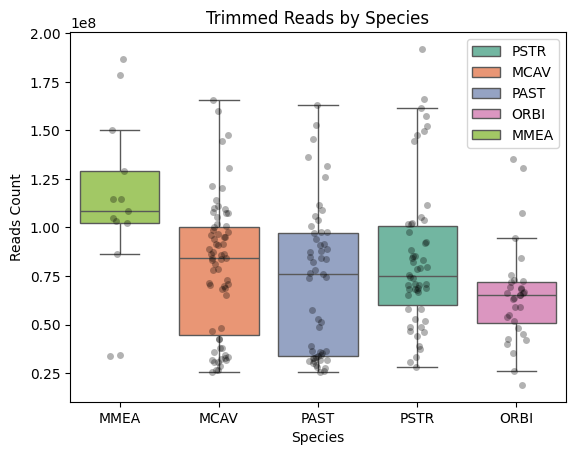

In [124]:
order = reads.groupby('Species')['trimmed'].median().sort_values(ascending=False).index
sns.boxplot(data=reads, x='Species', y='trimmed',
            order = order,
            palette = 'Set2',hue = 'Species',
            showfliers=False   # Points will be shown by stripplot instead
)
sns.stripplot(data=reads, x='Species', y='trimmed', color='black', 
    alpha=0.3, 
    jitter=True
)
plt.title('Trimmed Reads by Species')
plt.ylabel('Reads Count')
plt.xlabel('Species')

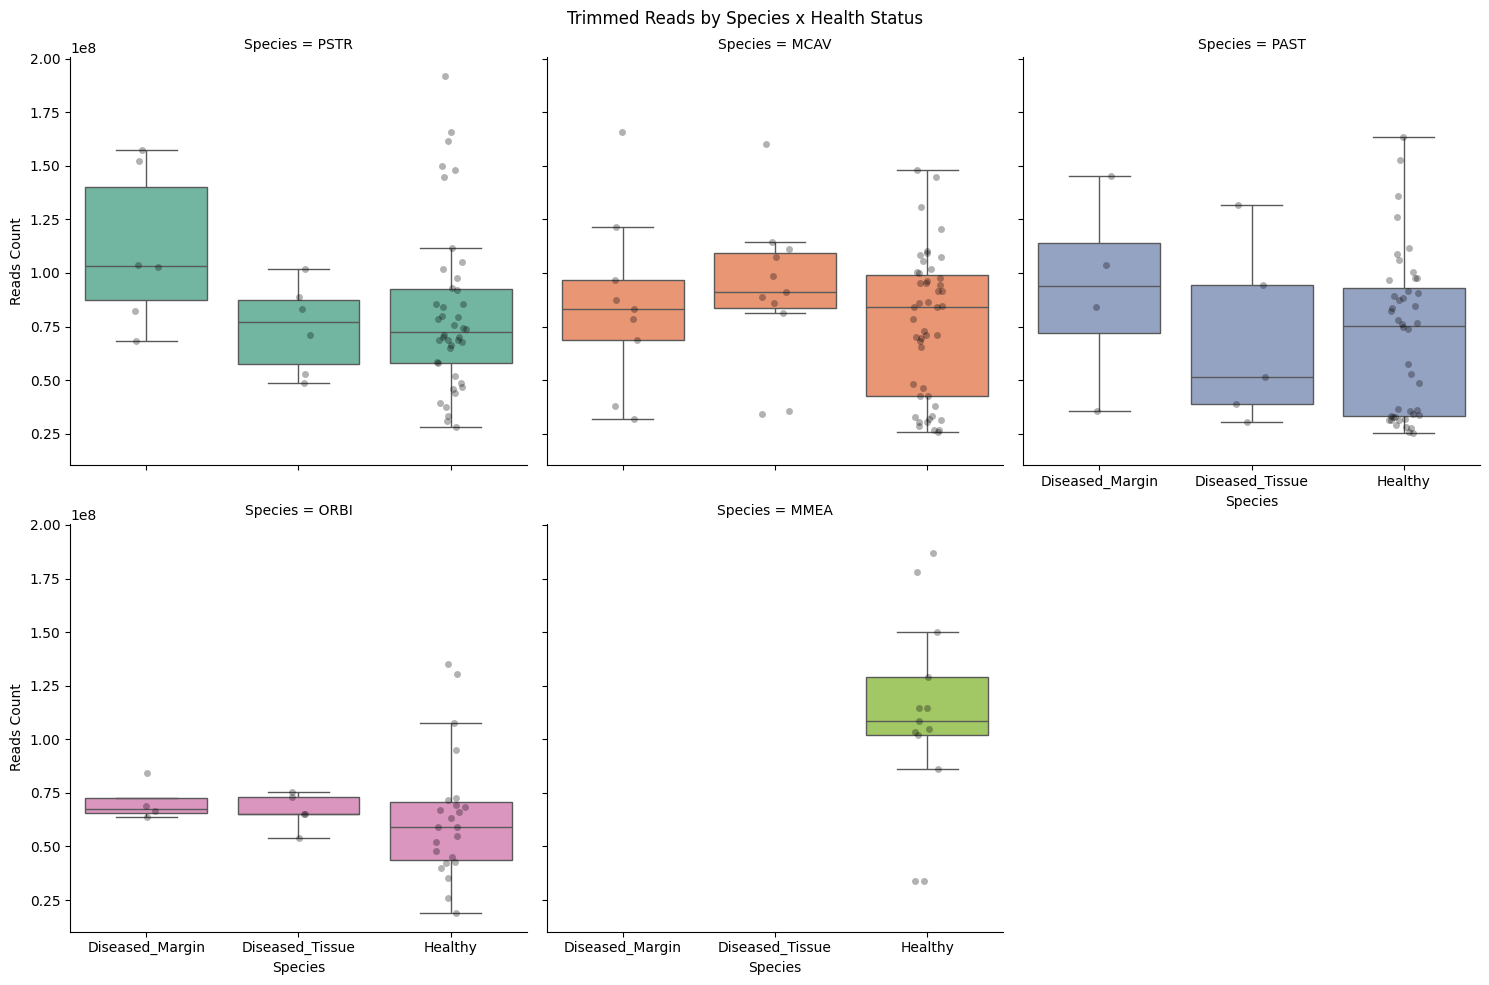

In [130]:
sp=sns.catplot(data=reads, x='Health_status', y='trimmed',col = 'Species',
            kind = 'box',
            palette = 'Set2',hue = 'Species',
            col_wrap = 3,
            showfliers=False,
            legend = False
)
sp.map_dataframe(sns.stripplot,x='Health_status', y='trimmed', color='black',
                 alpha=0.3, jitter=True
)
sp.fig.suptitle('Trimmed Reads by Species x Health Status')
sp.set_axis_labels('Species','Reads Count')
plt.tight_layout()
plt.show()

In [131]:
reads.head()

,sampleid,raw,trimmed,host_removal,human_symb_removal,repaired,Species,Transect,colony_id,Health_status,group,pct_host_aligned
0,052022_BEL_CBC_T1_10_PSTR,68572842.0,68449647.0,28910191.0,28187436.0,27922584.0,PSTR,CBC30N,T1_4_PSTR,Diseased_Margin,52022_PSTR_Diseased_Margin,57.764295
1,052022_BEL_CBC_T1_11_PSTR,48741905.0,48660782.0,23319939.0,20372298.0,20064803.0,PSTR,CBC30N,T1_4_PSTR,Diseased_Tissue,52022_PSTR_Diseased_Tissue,52.076522
2,052022_BEL_CBC_T1_12_MCAV,166267321.0,165624856.0,53609962.0,16897860.0,15467061.0,MCAV,CBC30N,T1_8_MCAV,Diseased_Margin,52022_MCAV_Diseased_Margin,67.631693
3,052022_BEL_CBC_T1_13_MCAV,86263796.0,86076666.0,82372839.0,8467927.0,6251710.0,MCAV,CBC30N,T1_8_MCAV,Diseased_Tissue,52022_MCAV_Diseased_Tissue,4.302940
4,052022_BEL_CBC_T1_1_PAST,85047990.0,84808864.0,83379066.0,79310167.0,78064852.0,PAST,CBC30N,T1_2_PAST,Healthy,52022_PAST_Healthy,1.685906


Text(0.5, 0, 'Species')

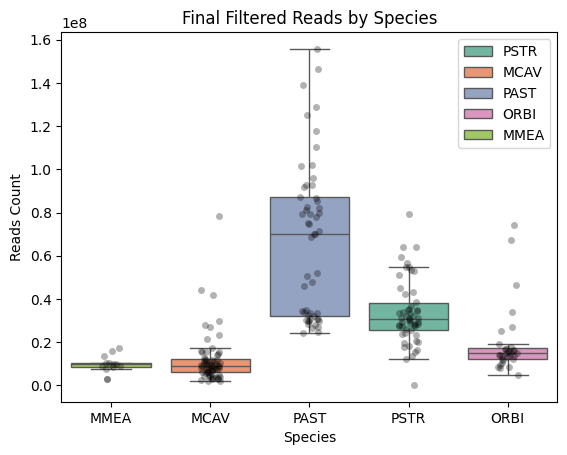

In [132]:
sns.boxplot(data=reads, x='Species', y='repaired',
            order = order,
            palette = 'Set2',hue = 'Species',
            showfliers=False
)
sns.stripplot(data=reads, x='Species', y='repaired', color='black', 
    alpha=0.3, 
    jitter=True
)
plt.title('Final Filtered Reads by Species')
plt.ylabel('Reads Count')
plt.xlabel('Species')

In [ ]:
# plot symbiont type matching over
